# Phase 2 — Études Statistiques
**Notebook :** `02_statistical_study.ipynb`  
**Problématique :** Comment une approche Demand-Driven s'appuyant sur l'IA peut-elle prédire la demande client réelle (Quantité + Date) pour optimiser la chaîne d'approvisionnement ?  
**Livrable :** `data/processed/dataset_ml_enrichi.parquet` + figures dans `reports/`

In [6]:
pip install requests


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import warnings
warnings.filterwarnings('ignore')   # masquer les avertissements pandas/statsmodels

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker  # formatage des axes (virgules dans les grands nombres)
import seaborn as sns                # heatmap pour la matrice de corrélation

# statsmodels : décomposition temporelle + test de Granger
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import grangercausalitytests

import holidays   # calendrier des jours fériés français

# Création des dossiers de sortie s'ils n'existent pas
os.makedirs('../reports', exist_ok=True)
os.makedirs('../data/external', exist_ok=True)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

print('Setup OK')

Setup OK


In [8]:
# Chargement du dataset produit en Phase 1 (349 390 lignes × 24 colonnes)
df = pd.read_parquet('../data/processed/dataset_ml_final.parquet')
print(f'Shape : {df.shape}')
print(df.dtypes)

Shape : (349390, 24)
qte_demandee                      int64
prix                            float64
annee_cmd                         int32
mois_cmd                          int32
trimestre_cmd                     int32
semaine_cmd                       int64
jour_semaine_cmd                  int32
est_fin_mois_cmd                  int64
annee_liv_dem                     int32
mois_liv_dem                      int32
trimestre_liv_dem                 int32
jour_semaine_liv_dem              int32
est_weekend_liv_dem               int64
delai_demande_jours               int64
statut_enc                        int64
devise_enc                        int64
pays_enc                          int64
famille_activite_client_enc       int64
famille_activite_article_enc      int64
segment_enc                       int64
type_activite_enc                 int64
code_client_freq                  int64
code_article_freq                 int64
en_retard                       float64
dtype: object


In [9]:
# Le dataset stocke l'année et le mois séparément (annee_cmd, mois_cmd).
# On reconstruit une vraie colonne datetime en fixant le jour à 1
# → chaque ligne est rattachée au 1er du mois de sa commande / livraison.
# Cela permet d'agréger par mois pour les séries temporelles.

df['date_cmd'] = pd.to_datetime(
    df[['annee_cmd', 'mois_cmd']].assign(day=1)
      .rename(columns={'annee_cmd': 'year', 'mois_cmd': 'month'})
)

df['date_liv_dem'] = pd.to_datetime(
    df[['annee_liv_dem', 'mois_liv_dem']].assign(day=1)
      .rename(columns={'annee_liv_dem': 'year', 'mois_liv_dem': 'month'})
)

print('Plage date_cmd    :', df['date_cmd'].min(), '→', df['date_cmd'].max())
print('Plage date_liv_dem:', df['date_liv_dem'].min(), '→', df['date_liv_dem'].max())
print('Lignes totales    :', len(df))

Plage date_cmd    : 2020-09-01 00:00:00 → 2025-12-01 00:00:00
Plage date_liv_dem: 2021-01-01 00:00:00 → 2025-12-01 00:00:00
Lignes totales    : 349390


---
## Étude A — Saisonnalité et Cyclicité

### A.1 — Décomposition de la série temporelle globale

In [10]:
# On additionne toutes les quantités demandées par mois → série temporelle globale.
# asfreq('MS') = Monthly Start : force une fréquence mensuelle régulière
# (si un mois est absent des données, il est ajouté avec 0)
serie_globale = (
    df.groupby('date_cmd')['qte_demandee']
      .sum()
      .sort_index()
      .asfreq('MS')
      .fillna(0)
)

print(f'Série globale : {len(serie_globale)} mois')
print(serie_globale.describe())

Série globale : 64 mois
count        64.000000
mean     124412.937500
std       41347.583631
min         300.000000
25%      104861.000000
50%      121658.500000
75%      142136.250000
max      244733.000000
Name: qte_demandee, dtype: float64


In [11]:
serie_globale.head()

date_cmd
2020-09-01       300
2020-10-01      1393
2020-11-01    120182
2020-12-01     36720
2021-01-01    178053
Freq: MS, Name: qte_demandee, dtype: int64

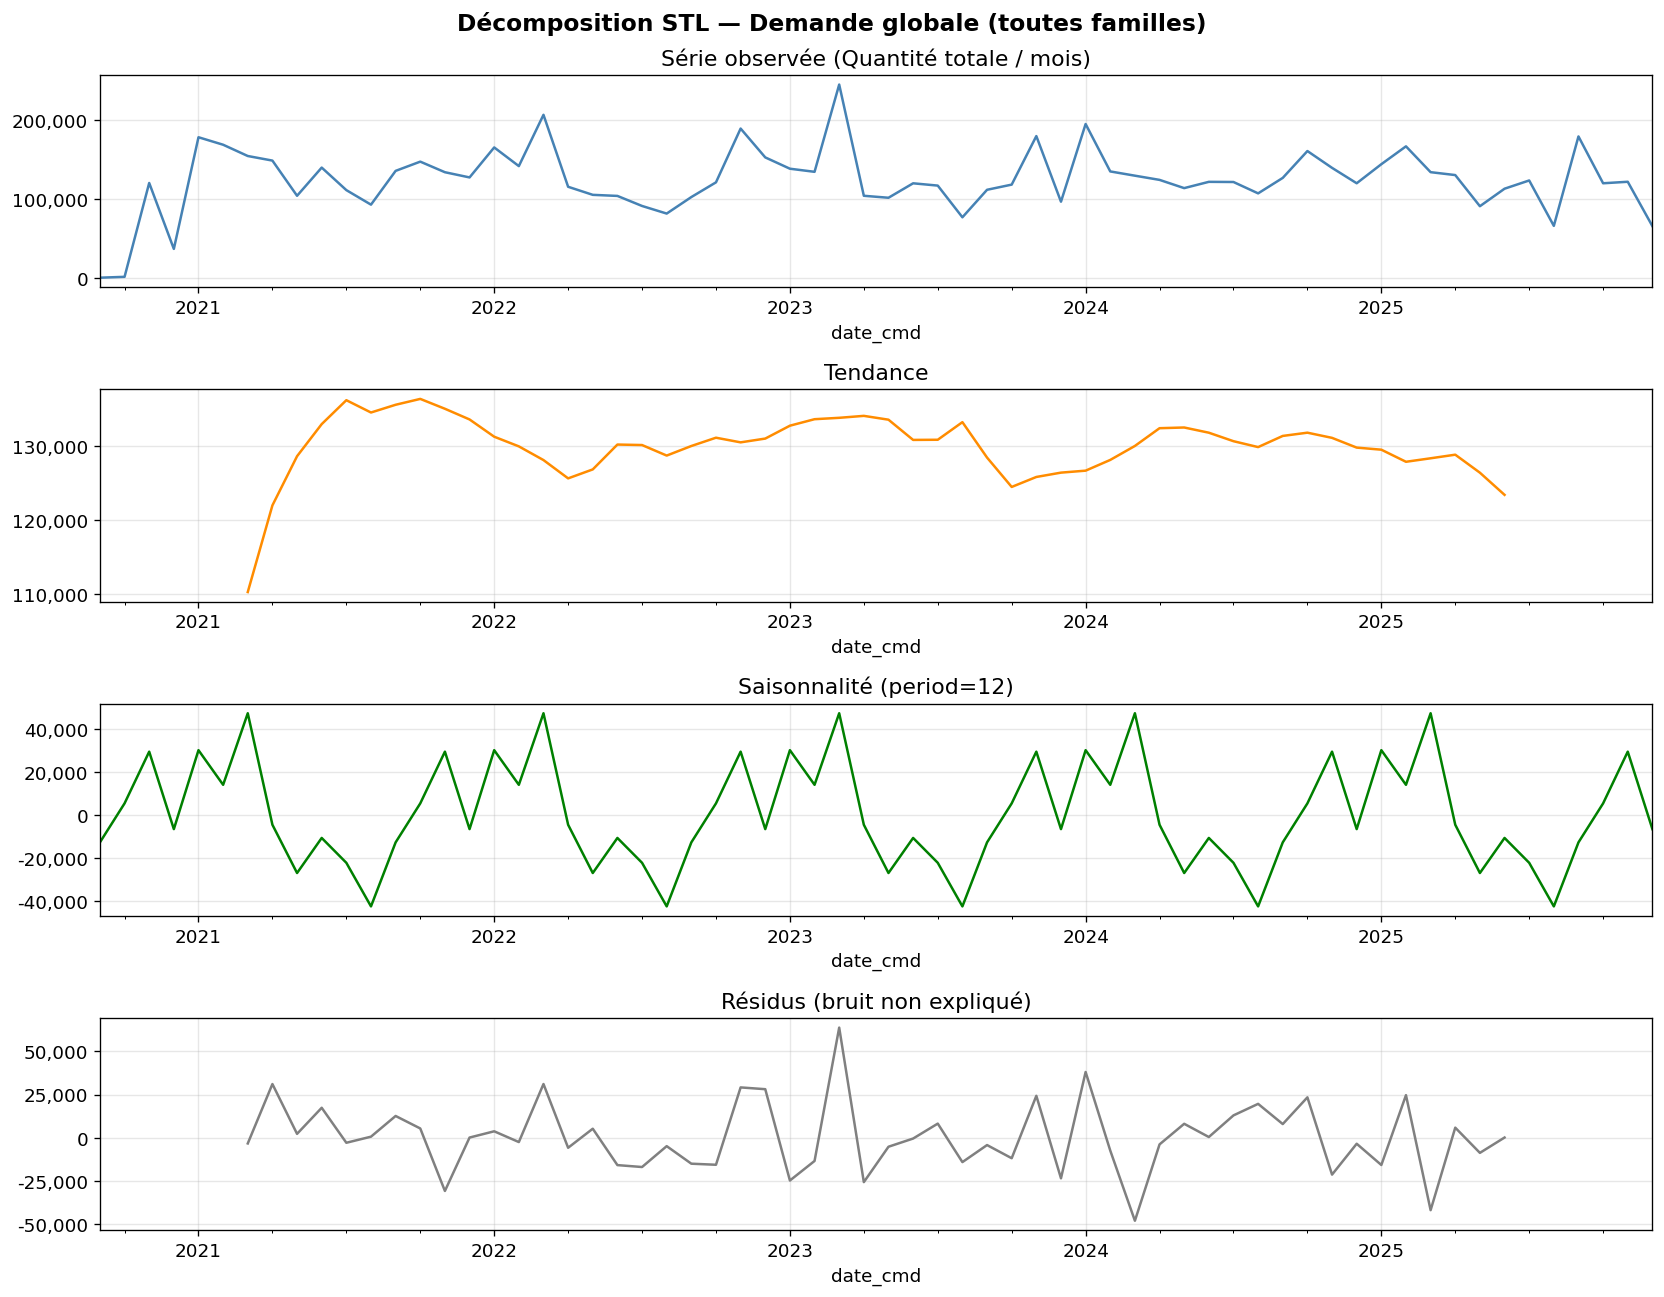

Sauvegardé → reports/decomposition_globale.png


In [12]:
# Décomposition additive : série = Tendance + Saisonnalité + Résidus
# model='additive' : les composantes s'additionnent (pas de multiplication)
# period=12 : on cherche un pattern annuel (12 mois)
decomp_global = seasonal_decompose(serie_globale, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 11))
fig.suptitle('Décomposition STL — Demande globale (toutes familles)', fontsize=14, fontweight='bold')

# 4 sous-graphes : série brute / tendance lissée / saisonnalité / résidus (bruit)
decomp_global.observed.plot(ax=axes[0], color='steelblue',  title='Série observée (Quantité totale / mois)')
decomp_global.trend.plot(   ax=axes[1], color='darkorange', title='Tendance')
decomp_global.seasonal.plot(ax=axes[2], color='green',      title='Saisonnalité (period=12)')
decomp_global.resid.plot(   ax=axes[3], color='gray',       title='Résidus (bruit non expliqué)')

for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/decomposition_globale.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé → reports/decomposition_globale.png')

In [13]:
# Lecture automatique des résultats de décomposition pour le mémoire
trend_vals       = decomp_global.trend.dropna()
delta_trend      = trend_vals.iloc[-1] - trend_vals.iloc[0]      # variation totale sur toute la période
amplitude_saison = decomp_global.seasonal.max() - decomp_global.seasonal.min()  # écart pic/creux annuel

# Mois avec la demande saisonnière la plus haute / la plus basse (moyenne sur toutes les années)
mois_pic   = decomp_global.seasonal.groupby(decomp_global.seasonal.index.month).mean().idxmax()
mois_creux = decomp_global.seasonal.groupby(decomp_global.seasonal.index.month).mean().idxmin()

print('=== Interprétation Décomposition Globale ===')
print(f'Tendance  : variation totale = {delta_trend:+,.0f} unités (tendance {"haussière" if delta_trend > 0 else "baissière"})')
print(f'Saisonnalité : amplitude pic/creux = {amplitude_saison:,.0f} unités')
print(f'  → Mois pic    : mois n°{mois_pic}')
print(f'  → Mois creux  : mois n°{mois_creux}')

=== Interprétation Décomposition Globale ===
Tendance  : variation totale = +13,130 unités (tendance haussière)
Saisonnalité : amplitude pic/creux = 89,725 unités
  → Mois pic    : mois n°3
  → Mois creux  : mois n°8


### A.2 — Décomposition par famille d'article

In [14]:
familles = sorted(df['famille_activite_article_enc'].unique())
print(f'Familles présentes : {familles}')
print(df.groupby('famille_activite_article_enc')['qte_demandee'].agg(['sum','count']))

Familles présentes : [np.int64(0), np.int64(1), np.int64(2)]
                                  sum   count
famille_activite_article_enc                 
0                             7119204  338517
1                              562156    3669
2                              281068    7204


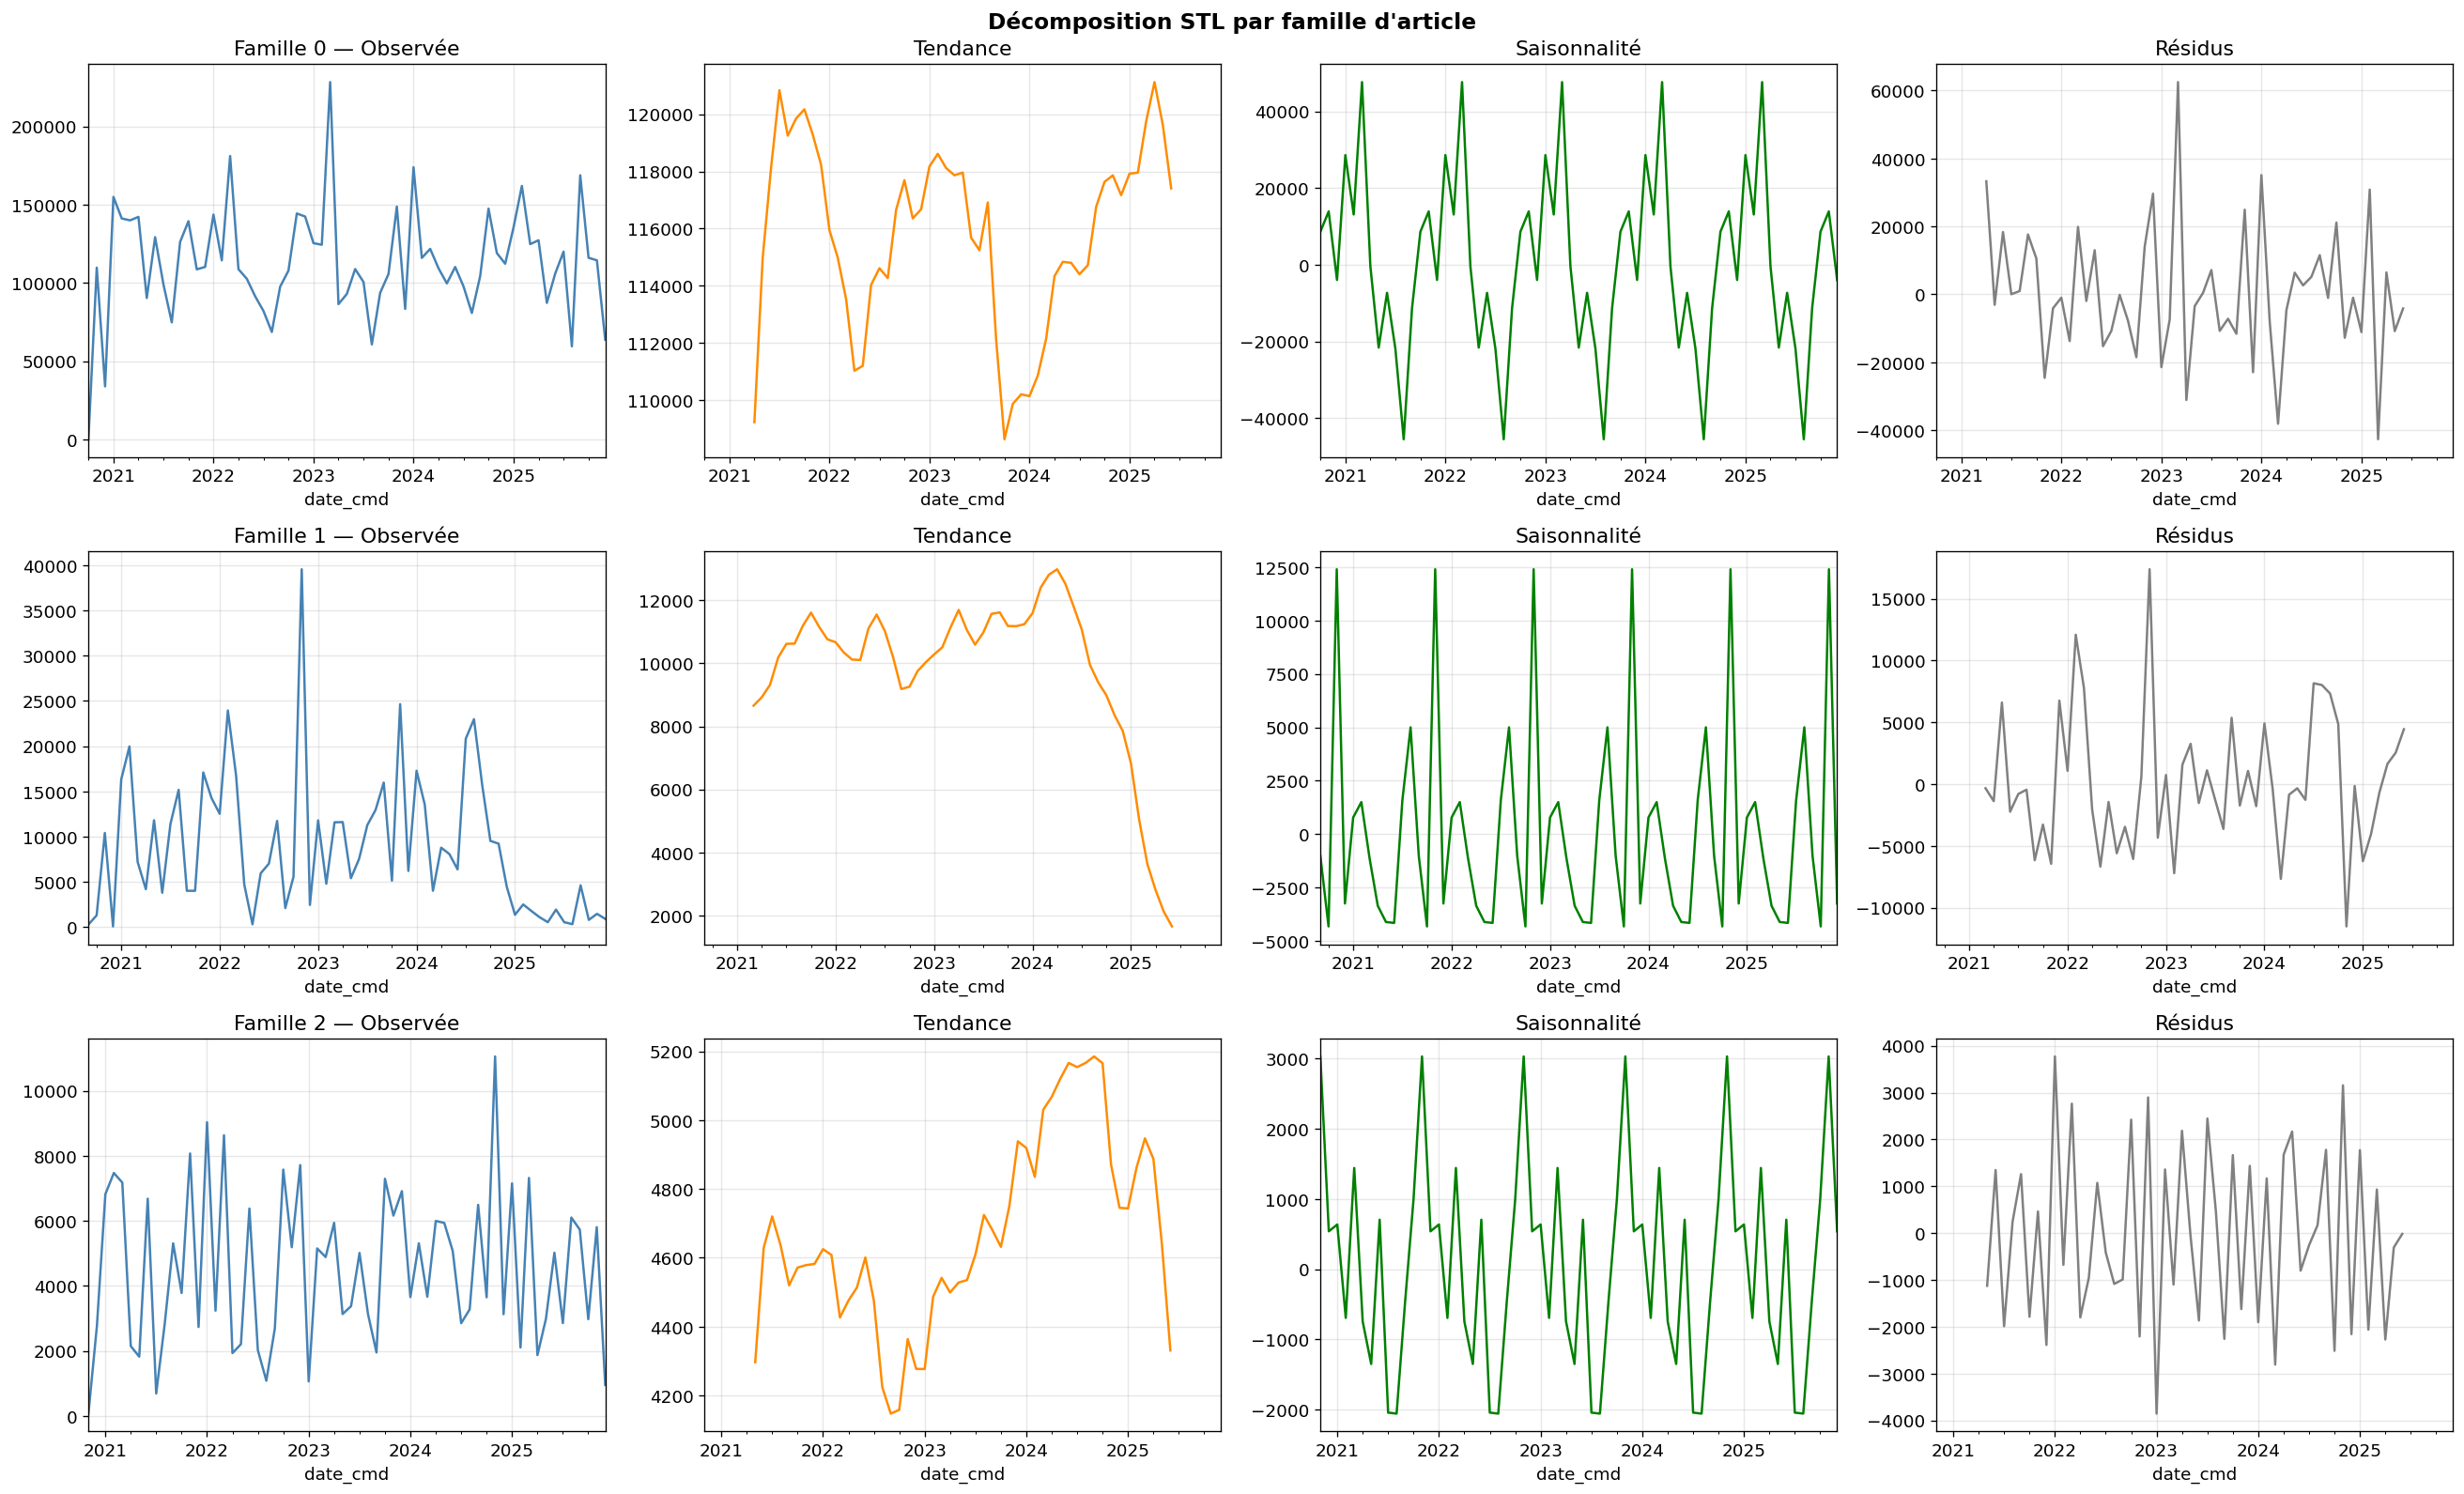

Sauvegardé → reports/decomposition_par_famille.png


In [15]:
n_familles = len(familles)
fig, axes = plt.subplots(n_familles, 4, figsize=(22, 4.5 * n_familles))
fig.suptitle('Décomposition STL par famille d\'article', fontsize=14, fontweight='bold')

for i, famille in enumerate(familles):
    subset = df[df['famille_activite_article_enc'] == famille]
    serie = (
        subset.groupby('date_cmd')['qte_demandee']
              .sum()
              .sort_index()
              .asfreq('MS')
              .fillna(0)
    )

    row = axes[i] if n_familles > 1 else axes

    if len(serie.dropna()) >= 24:
        decomp = seasonal_decompose(serie, model='additive', period=12)
        decomp.observed.plot( ax=row[0], title=f'Famille {famille} — Observée',   color='steelblue')
        decomp.trend.plot(    ax=row[1], title='Tendance',                        color='darkorange')
        decomp.seasonal.plot( ax=row[2], title='Saisonnalité',                    color='green')
        decomp.resid.plot(    ax=row[3], title='Résidus',                         color='gray')
        for ax in row:
            ax.grid(alpha=0.3)
    else:
        row[0].text(0.5, 0.5, f'Famille {famille}\nDonnées insuffisantes\n({len(serie)} mois)',
                   ha='center', va='center', transform=row[0].transAxes)
        for ax in row[1:]:
            ax.axis('off')

plt.tight_layout()
plt.savefig('../reports/decomposition_par_famille.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé → reports/decomposition_par_famille.png')

### A.3 — Cycles budgétaires clients (fin de trimestre)

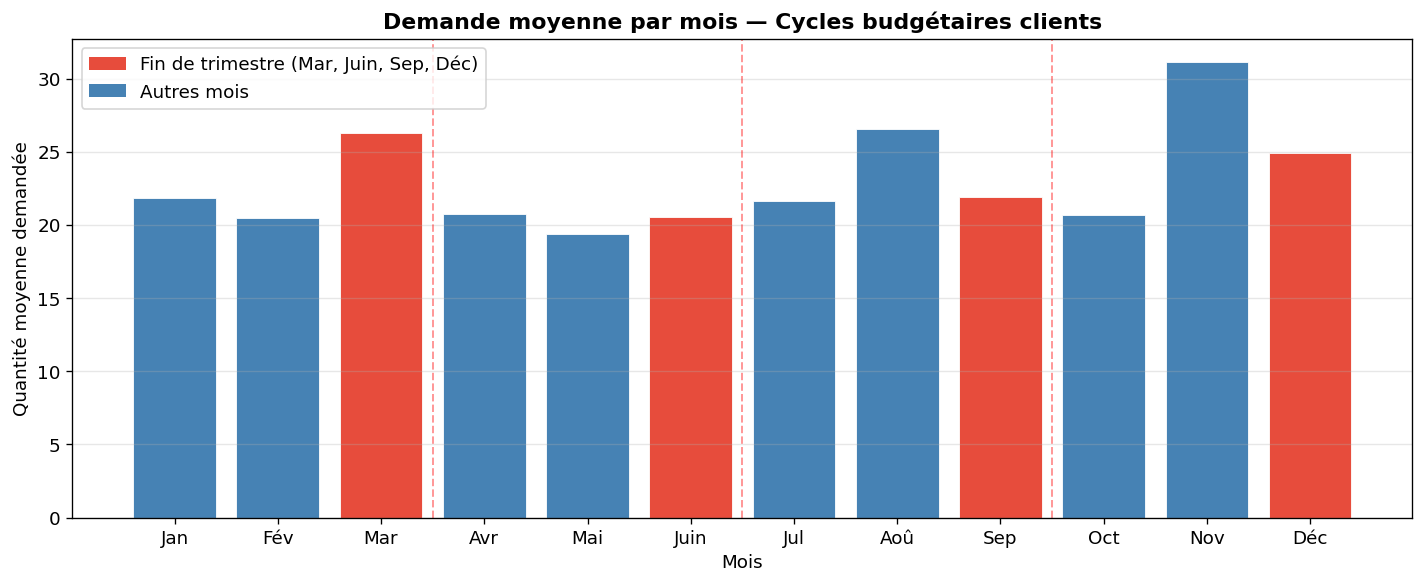

Sauvegardé → reports/cycles_budgetaires.png


In [16]:
demande_par_mois = df.groupby('mois_cmd')['qte_demandee'].mean().sort_index()

couleurs = ['#e74c3c' if m in [3, 6, 9, 12] else 'steelblue' for m in demande_par_mois.index]
mois_labels = ['Jan','Fév','Mar','Avr','Mai','Juin','Jul','Aoû','Sep','Oct','Nov','Déc']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(1, 13), demande_par_mois.values, color=couleurs, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(mois_labels)
ax.set_title('Demande moyenne par mois — Cycles budgétaires clients', fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('Quantité moyenne demandée')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Lignes de fin de trimestre
for x in [3.5, 6.5, 9.5]:
    ax.axvline(x=x, color='red', linestyle='--', alpha=0.4, linewidth=1.2)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Fin de trimestre (Mar, Juin, Sep, Déc)'),
                   Patch(facecolor='steelblue', label='Autres mois')]
ax.legend(handles=legend_elements)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/cycles_budgetaires.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé → reports/cycles_budgetaires.png')

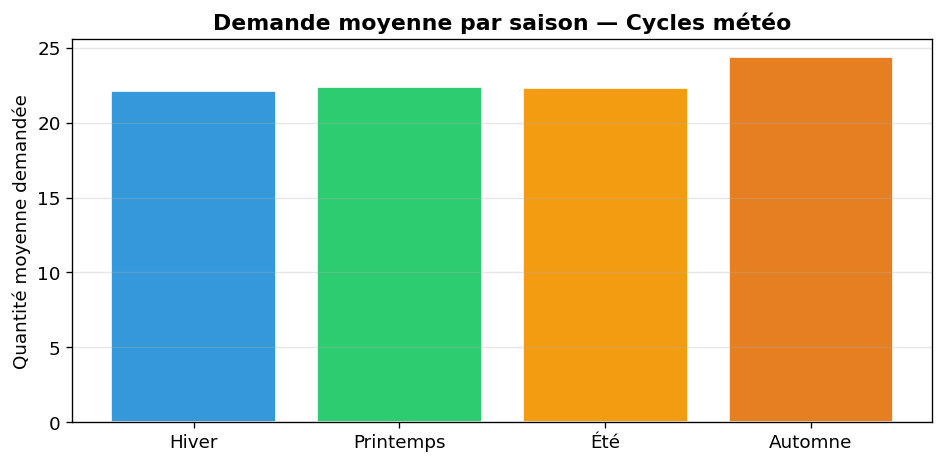


Demande moyenne par saison :
saison
Hiver        22.1
Printemps    22.4
Été          22.3
Automne      24.4
Name: qte_demandee, dtype: str


In [17]:
# Cycles météo — mois d'hiver vs été
df['saison'] = df['mois_cmd'].map({
    12: 'Hiver', 1: 'Hiver', 2: 'Hiver',
    3: 'Printemps', 4: 'Printemps', 5: 'Printemps',
    6: 'Été', 7: 'Été', 8: 'Été',
    9: 'Automne', 10: 'Automne', 11: 'Automne'
})

demande_saison = df.groupby('saison')['qte_demandee'].mean().reindex(['Hiver','Printemps','Été','Automne'])

fig, ax = plt.subplots(figsize=(8, 4))
couleurs_saison = ['#3498db', '#2ecc71', '#f39c12', '#e67e22']
ax.bar(demande_saison.index, demande_saison.values, color=couleurs_saison, edgecolor='white')
ax.set_title('Demande moyenne par saison — Cycles météo', fontweight='bold')
ax.set_ylabel('Quantité moyenne demandée')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/cycles_meteo.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDemande moyenne par saison :')
print(demande_saison.apply(lambda x: f'{x:,.1f}'))

---
## Étude B — Corrélations Exogènes (Facteurs Externes)

### B.1.1 — Variables jours fériés (France)

In [18]:
# Création du calendrier des jours fériés français (2020-2025)
cal_fr = holidays.France()

# Retourne 1 si la date tombe un jour férié, 0 sinon
def est_ferie_fr(date):
    return int(date in cal_fr)

# Compte les jours fériés tombant un jour ouvré entre date_debut et date_fin
# → mesure les interruptions potentielles pendant le délai de livraison
def nb_feries_dans_intervalle(date_debut, date_fin):
    if pd.isna(date_debut) or pd.isna(date_fin) or date_fin < date_debut:
        return 0
    jours = pd.date_range(date_debut, date_fin, freq='B')  # freq='B' = jours ouvrés seulement
    return int(sum(1 for j in jours if j in cal_fr))

# Compte les jours de week-end dans l'intervalle (samedi=5, dimanche=6)
def nb_weekends_dans_intervalle(date_debut, date_fin):
    if pd.isna(date_debut) or pd.isna(date_fin) or date_fin < date_debut:
        return 0
    jours = pd.date_range(date_debut, date_fin)
    return int(sum(1 for j in jours if j.weekday() >= 5))

# Application sur chaque ligne du dataset
df['est_jour_ferie_cmd']         = df['date_cmd'].apply(est_ferie_fr)
df['est_jour_ferie_liv_dem']     = df['date_liv_dem'].apply(est_ferie_fr)
df['nb_jours_feries_dans_delai'] = df.apply(
    lambda r: nb_feries_dans_intervalle(r['date_cmd'], r['date_liv_dem']), axis=1)
df['nb_weekends_dans_delai']     = df.apply(
    lambda r: nb_weekends_dans_intervalle(r['date_cmd'], r['date_liv_dem']), axis=1)

print('Variables jours fériés créées :')
print(df[['est_jour_ferie_cmd','est_jour_ferie_liv_dem',
          'nb_jours_feries_dans_delai','nb_weekends_dans_delai']].describe())

Variables jours fériés créées :
       est_jour_ferie_cmd  est_jour_ferie_liv_dem  nb_jours_feries_dans_delai  \
count       349390.000000           349390.000000               349390.000000   
mean             0.283766                0.286393                    0.343155   
std              0.450825                0.452076                    0.653490   
min              0.000000                0.000000                    0.000000   
25%              0.000000                0.000000                    0.000000   
50%              0.000000                0.000000                    0.000000   
75%              1.000000                1.000000                    1.000000   
max              1.000000                1.000000                   11.000000   

       nb_weekends_dans_delai  
count           349390.000000  
mean                 2.115229  
std                  4.088898  
min                  0.000000  
25%                  0.000000  
50%                  0.000000  
75%           

### B.1.2 — Variables météo (Open-Meteo — proxy Paris)

In [19]:
import urllib.request
import urllib.parse
import json

# Open-Meteo Archive API : on récupère en DAILY puis on agrège en mensuel
# Paris comme proxy France (89% des commandes GE)
params = {
    'latitude':   '48.85',
    'longitude':  '2.35',
    'start_date': '2020-01-01',
    'end_date':   '2025-12-31',
    'daily':      ['precipitation_sum', 'wind_speed_10m_max', 'temperature_2m_min'],
    'timezone':   'Europe/Paris',
}
url = 'https://archive-api.open-meteo.com/v1/archive?' + urllib.parse.urlencode(params, doseq=True)

with urllib.request.urlopen(url, timeout=30) as resp:
    data = json.loads(resp.read().decode())

# Construction du DataFrame daily
daily = data['daily']
meteo_daily = pd.DataFrame({
    'date':             pd.to_datetime(daily['time']),
    'pluie_mm':         daily['precipitation_sum'],
    'vent_max_kmh':     daily['wind_speed_10m_max'],
    'temp_min_celsius': daily['temperature_2m_min'],
})

# Agrégation mensuelle : somme pour la pluie, max pour le vent, min pour la temp
meteo_fr = (
    meteo_daily
    .set_index('date')
    .resample('MS')   # MS = début de mois
    .agg({
        'pluie_mm':         'sum',
        'vent_max_kmh':     'max',
        'temp_min_celsius': 'min',
    })
    .rename(columns={'pluie_mm': 'pluie_mm_mois'})
    .reset_index()
)

print('Météo mensuelle récupérée :')
print(meteo_fr.head())
print(f'\n{len(meteo_fr)} mois de données météo')

Météo mensuelle récupérée :
        date  pluie_mm_mois  vent_max_kmh  temp_min_celsius
0 2020-01-01           29.4          36.7              -3.2
1 2020-02-01          103.7          49.1              -1.3
2 2020-03-01           67.7          42.3              -0.6
3 2020-04-01           30.4          35.1              -0.9
4 2020-05-01           37.3          36.5               4.3

72 mois de données météo


In [20]:
# Jointure météo sur le mois de livraison demandée.
# On convertit les deux dates en "1er du mois" pour faire coïncider les clés de jointure.
df['mois_liv_dem_dt'] = df['date_liv_dem'].dt.to_period('M').dt.to_timestamp()
meteo_fr['date']      = meteo_fr['date'].dt.to_period('M').dt.to_timestamp()

# LEFT JOIN : toutes les lignes du dataset sont conservées
# Si une date de livraison est hors plage météo → NaN (on vérifie en dessous)
df = df.merge(
    meteo_fr.rename(columns={
        'pluie_mm_mois':    'pluie_mm_liv_dem',
        'vent_max_kmh':     'vent_max_kmh_liv_dem',
        'temp_min_celsius': 'temp_min_liv_dem'
    }),
    left_on='mois_liv_dem_dt', right_on='date', how='left'
).drop(columns=['date'])  # supprime la colonne 'date' dupliquée après fusion

print('NaN météo :', df[['pluie_mm_liv_dem','vent_max_kmh_liv_dem','temp_min_liv_dem']].isna().sum().to_dict())

NaN météo : {'pluie_mm_liv_dem': 0, 'vent_max_kmh_liv_dem': 0, 'temp_min_liv_dem': 0}


### B.1.3 — Indice de Production Industrielle France (INSEE)

In [21]:
# Chargement IPI depuis les fichiers INSEE téléchargés (NACE 41 — Construction de bâtiments, base 100=2021)
# Fichier valeurs_mensuelles.csv : 4 lignes d'en-tête INSEE, puis YYYY-MM ; valeur ; code
IPI_VALUES  = '../data/external/valeurs_mensuelles.csv'
IPI_LEGACY  = '../data/external/ipi_france.csv'

def charger_ipi_insee(path):
    """Parse le format INSEE standard : 4 lignes de méta, puis YYYY-MM;valeur;code."""
    raw = pd.read_csv(path, sep=';', header=None, skiprows=4, dtype=str)
    raw = raw[[0, 1]].copy()
    raw.columns = ['periode', 'ipi_valeur']
    # Garder uniquement les lignes dont la période est au format YYYY-MM
    raw = raw[raw['periode'].str.match(r'^\d{4}-\d{2}$', na=False)].copy()
    raw['date']      = pd.to_datetime(raw['periode'] + '-01')
    raw['ipi_valeur'] = pd.to_numeric(raw['ipi_valeur'], errors='coerce')
    return raw[['date', 'ipi_valeur']].dropna().sort_values('date').reset_index(drop=True)

if os.path.exists(IPI_VALUES):
    ipi = charger_ipi_insee(IPI_VALUES)
    print(f'IPI chargé depuis {IPI_VALUES}  ({len(ipi)} mois, NACE 41 Construction, base 2021)')
elif os.path.exists(IPI_LEGACY):
    ipi = pd.read_csv(IPI_LEGACY, parse_dates=['date'])
    ipi['date'] = ipi['date'].dt.to_period('M').dt.to_timestamp()
    print(f'IPI chargé depuis {IPI_LEGACY} ({len(ipi)} mois)')
else:
    # Fallback hardcodé — NACE 41 Construction de bâtiments, base 100=2021 (source INSEE)
    ipi_dict = {
        '2020-01': 111.32, '2020-02': 115.04, '2020-03':  76.64, '2020-04':  39.34,
        '2020-05':  85.15, '2020-06': 109.41, '2020-07': 113.09, '2020-08':  75.67,
        '2020-09': 109.83, '2020-10': 112.86, '2020-11': 111.05, '2020-12':  91.55,
        '2021-01': 100.70, '2021-02': 102.78, '2021-03': 109.56, '2021-04': 103.72,
        '2021-05': 103.65, '2021-06': 109.42, '2021-07': 104.64, '2021-08':  64.38,
        '2021-09': 103.38, '2021-10': 106.62, '2021-11': 105.83, '2021-12':  85.33,
        '2022-01':  95.02, '2022-02': 100.31, '2022-03': 105.84, '2022-04':  98.51,
        '2022-05': 102.91, '2022-06': 103.71, '2022-07':  98.21, '2022-08':  64.25,
        '2022-09': 101.54, '2022-10': 104.60, '2022-11': 106.10, '2022-12':  84.32,
        '2023-01':  95.35, '2023-02': 101.54, '2023-03': 106.61, '2023-04': 100.13,
        '2023-05': 104.67, '2023-06': 107.76, '2023-07': 101.69, '2023-08':  63.08,
        '2023-09':  99.76, '2023-10': 104.25, '2023-11': 102.27, '2023-12':  79.75,
        '2024-01':  92.64, '2024-02':  97.14, '2024-03':  97.27, '2024-04':  94.09,
        '2024-05':  94.78, '2024-06':  98.24, '2024-07':  95.25, '2024-08':  55.64,
        '2024-09':  91.22, '2024-10':  96.50, '2024-11':  95.30, '2024-12':  77.28,
        '2025-01':  84.17, '2025-02':  88.94, '2025-03':  90.50, '2025-04':  89.30,
        '2025-05':  88.96, '2025-06':  91.20, '2025-07':  91.90, '2025-08':  54.06,
        '2025-09':  88.61, '2025-10':  93.01, '2025-11':  88.42, '2025-12':  75.10,
    }
    ipi = pd.DataFrame([
        {'date': pd.to_datetime(k + '-01'), 'ipi_valeur': v}
        for k, v in ipi_dict.items()
    ])
    print('AVERTISSEMENT : fichiers INSEE non trouvés — valeurs hardcodées NACE 41 utilisées.')

print(ipi.head())
print(f'Plage : {ipi["date"].min().date()} → {ipi["date"].max().date()}')

# Jointure sur le mois de commande
df['mois_cmd_dt'] = df['date_cmd'].dt.to_period('M').dt.to_timestamp()
df = df.merge(
    ipi.rename(columns={'date': 'mois_cmd_dt'}),
    on='mois_cmd_dt', how='left'
)

print(f"\nNaN IPI : {df['ipi_valeur'].isna().sum()}")
print(df['ipi_valeur'].describe())

IPI chargé depuis ../data/external/valeurs_mensuelles.csv  (75 mois, NACE 41 Construction, base 2021)
        date  ipi_valeur
0 2020-01-01      111.32
1 2020-02-01      115.04
2 2020-03-01       76.64
3 2020-04-01       39.34
4 2020-05-01       85.15
Plage : 2020-01-01 → 2026-03-01

NaN IPI : 0
count    349390.000000
mean         95.872387
std          10.778314
min          54.060000
25%          91.200000
50%          98.210000
75%         103.650000
max         112.860000
Name: ipi_valeur, dtype: float64


### B.1.4 — Taux de change (EUR / USD / CNY)

In [22]:
# Mapping devise_enc → devise (déduit des données sources)
# 0=CNY (2 lignes), 1=EUR (348 312 lignes), 2=USD (1 076 lignes)
devise_map = {0: 'CNY', 1: 'EUR', 2: 'USD'}

taux_change_table = {
    ('EUR', 2020): 1.000, ('EUR', 2021): 1.000, ('EUR', 2022): 1.000,
    ('EUR', 2023): 1.000, ('EUR', 2024): 1.000, ('EUR', 2025): 1.000,
    ('USD', 2020): 1.141, ('USD', 2021): 1.183, ('USD', 2022): 1.053,
    ('USD', 2023): 1.081, ('USD', 2024): 1.082, ('USD', 2025): 1.073,
    ('CNY', 2020): 7.874, ('CNY', 2021): 7.628, ('CNY', 2022): 7.079,
    ('CNY', 2023): 7.653, ('CNY', 2024): 7.818, ('CNY', 2025): 7.750,
}

def get_taux(row):
    devise = devise_map.get(row['devise_enc'], 'EUR')
    annee  = row['annee_cmd']
    return taux_change_table.get((devise, annee), 1.0)

df['taux_change_devise'] = df.apply(get_taux, axis=1)

print('Distribution taux de change :')
print(df['taux_change_devise'].value_counts())

Distribution taux de change :
taux_change_devise
1.000    348312
1.081       299
1.082       271
1.053       223
1.073       142
1.183       135
1.141         6
7.628         2
Name: count, dtype: int64


### B.1.5 — Variables contextuelles (vacances, peak, COVID)

In [23]:
# Vacances scolaires France (toutes zones A, B, C)
vacances_fr = [
    ('2021-02-06','2021-03-07'), ('2021-04-10','2021-04-25'),
    ('2021-07-07','2021-08-31'), ('2021-10-23','2021-11-07'), ('2021-12-18','2022-01-02'),
    ('2022-02-05','2022-03-06'), ('2022-04-09','2022-04-24'),
    ('2022-07-07','2022-08-31'), ('2022-10-22','2022-11-06'), ('2022-12-17','2023-01-02'),
    ('2023-02-04','2023-03-05'), ('2023-04-08','2023-04-23'),
    ('2023-07-08','2023-08-31'), ('2023-10-21','2023-11-05'), ('2023-12-23','2024-01-07'),
    ('2024-02-10','2024-03-10'), ('2024-04-06','2024-04-21'),
    ('2024-07-06','2024-08-31'), ('2024-10-19','2024-11-03'), ('2024-12-21','2025-01-05'),
    ('2025-02-08','2025-03-09'), ('2025-04-05','2025-04-20'),
    ('2025-07-05','2025-08-31'), ('2025-10-18','2025-11-02'), ('2025-12-20','2026-01-04'),
]
vacances_intervals = [(pd.Timestamp(d), pd.Timestamp(f)) for d, f in vacances_fr]

covid_intervals = [
    (pd.Timestamp('2021-01-01'), pd.Timestamp('2021-06-30')),
    (pd.Timestamp('2022-01-01'), pd.Timestamp('2022-03-31')),
]

def est_vacances(date):
    return int(any(d <= date <= f for d, f in vacances_intervals))

def est_covid(date):
    return int(any(d <= date <= f for d, f in covid_intervals))

# Périodes de forte demande : rentrée (sep), Black Friday / Noël (nov, déc)
df['est_vacances_scolaires_liv_dem'] = df['date_liv_dem'].apply(est_vacances)
df['est_periode_peak_liv_dem']       = df['mois_liv_dem'].isin([9, 11, 12]).astype(int)
df['est_periode_covid']              = df['date_cmd'].apply(est_covid)

print('Variables contextuelles créées :')
for col in ['est_vacances_scolaires_liv_dem','est_periode_peak_liv_dem','est_periode_covid']:
    print(f'  {col}: {df[col].value_counts().to_dict()}')

Variables contextuelles créées :
  est_vacances_scolaires_liv_dem: {0: 241403, 1: 107987}
  est_periode_peak_liv_dem: {0: 272726, 1: 76664}
  est_periode_covid: {0: 286086, 1: 63304}


### B.2 — Matrice de corrélation de Pearson

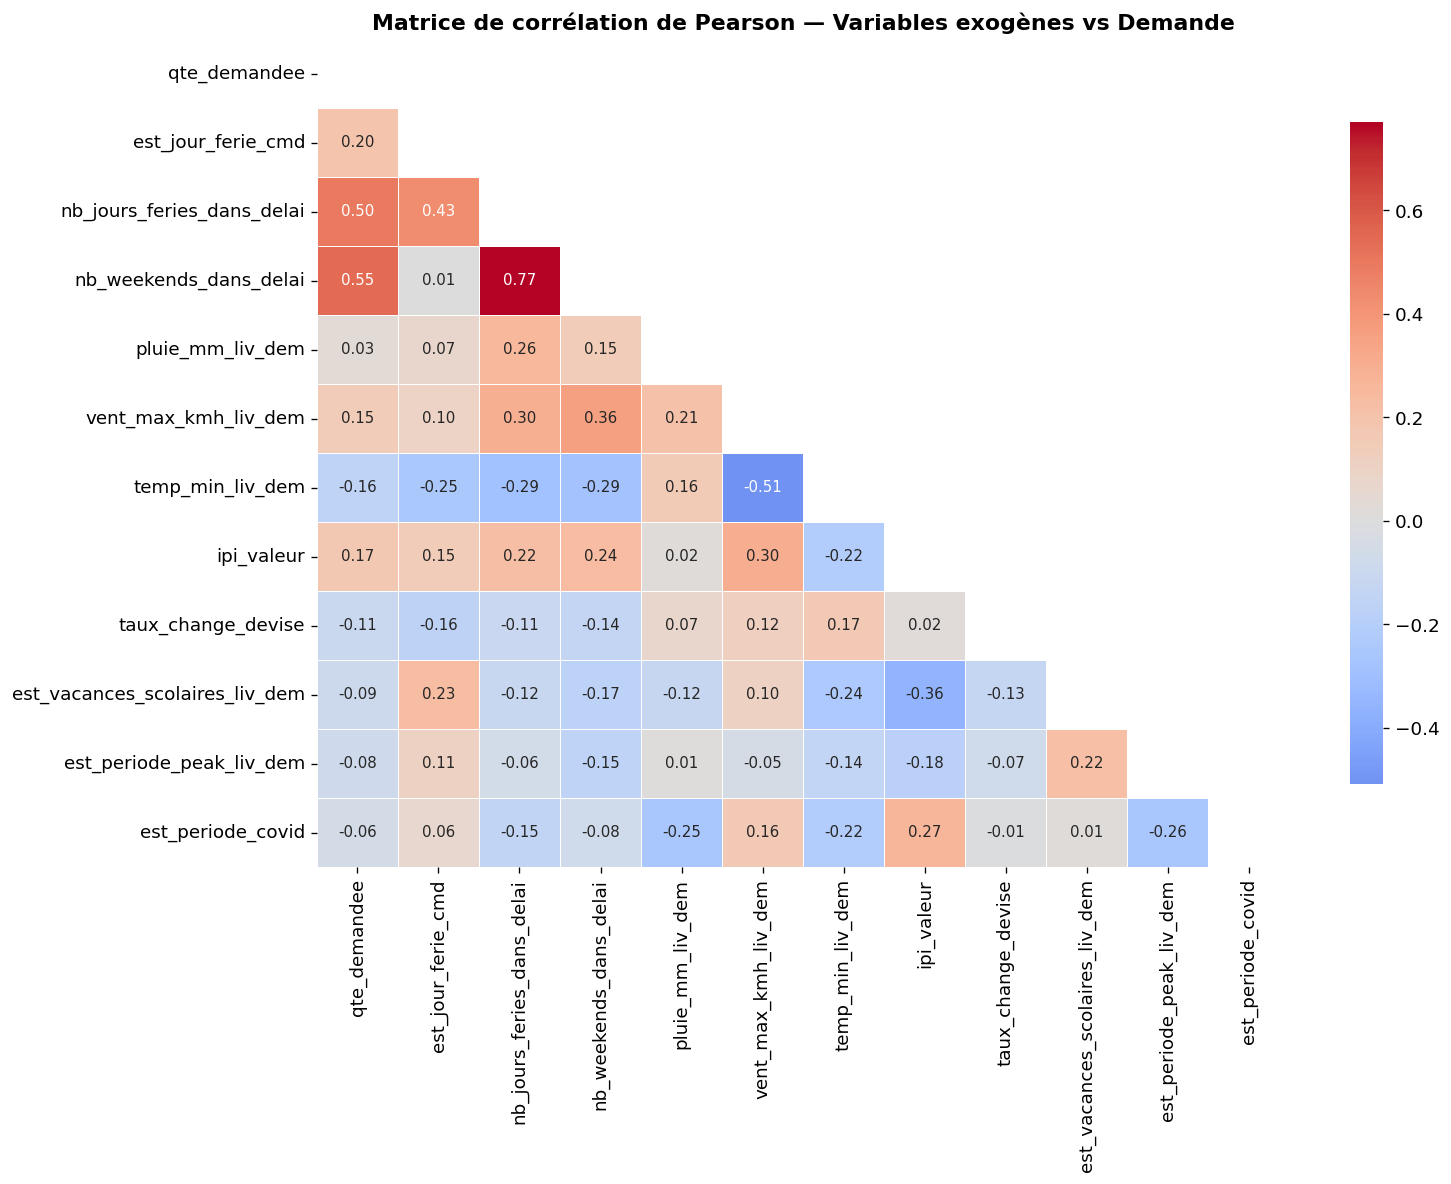

Sauvegardé → reports/matrice_correlation_pearson.png


In [24]:
# Liste des variables à analyser (cible + facteurs externes)
vars_exogenes = [
    'qte_demandee',                       # variable cible
    'est_jour_ferie_cmd',                 # commande passée un jour férié ?
    'nb_jours_feries_dans_delai',         # nb fériés pendant le délai de livraison
    'nb_weekends_dans_delai',             # nb week-ends pendant le délai
    'pluie_mm_liv_dem',                   # pluie au mois de livraison
    'vent_max_kmh_liv_dem',               # vent max au mois de livraison
    'temp_min_liv_dem',                   # température min au mois de livraison
    'ipi_valeur',                         # indice de production industrielle France
    'taux_change_devise',                 # taux EUR/USD/CNY selon la devise de la commande
    'est_vacances_scolaires_liv_dem',     # livraison pendant vacances scolaires ?
    'est_periode_peak_liv_dem',           # livraison en période de forte demande (sep/nov/déc) ?
    'est_periode_covid',                  # commande passée pendant perturbation COVID ?
]

# Agrégation mensuelle : on passe de 349 390 lignes à ~72 mois
# → niveau macro cohérent pour analyser les corrélations temporelles
df_mensuel = df.groupby('mois_cmd_dt')[vars_exogenes].mean()

# Corrélation de Pearson : mesure la relation linéaire entre chaque paire de variables
# r = +1 → corrélation parfaite positive, r = -1 → inverse, r = 0 → aucune relation
corr_matrix = df_mensuel.corr(method='pearson')

fig, ax = plt.subplots(figsize=(13, 10))

# mask : on n'affiche que le triangle inférieur pour éviter la redondance
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax, mask=mask,
    annot_kws={'size': 9}, cbar_kws={'shrink': 0.8}
)
ax.set_title('Matrice de corrélation de Pearson — Variables exogènes vs Demande', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/matrice_correlation_pearson.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé → reports/matrice_correlation_pearson.png')

In [25]:
corr_avec_cible = (
    corr_matrix['qte_demandee']
    .drop('qte_demandee')
    .sort_values(key=abs, ascending=False)
)

print('=== Corrélation Pearson avec qte_demandee ===')
for var, val in corr_avec_cible.items():
    signe = '▲' if val > 0 else '▼'
    print(f'  {signe} {var:<38} r = {val:+.3f}  {"★" if abs(val) > 0.15 else ""}')

print(f'\nSeuil |Pearson| > 0.15 : {(corr_avec_cible.abs() > 0.15).sum()} variable(s) retenue(s) pour Granger')

=== Corrélation Pearson avec qte_demandee ===
  ▲ nb_weekends_dans_delai                 r = +0.545  ★
  ▲ nb_jours_feries_dans_delai             r = +0.497  ★
  ▲ est_jour_ferie_cmd                     r = +0.198  ★
  ▲ ipi_valeur                             r = +0.174  ★
  ▼ temp_min_liv_dem                       r = -0.156  ★
  ▲ vent_max_kmh_liv_dem                   r = +0.149  
  ▼ taux_change_devise                     r = -0.106  
  ▼ est_vacances_scolaires_liv_dem         r = -0.093  
  ▼ est_periode_peak_liv_dem               r = -0.080  
  ▼ est_periode_covid                      r = -0.058  
  ▲ pluie_mm_liv_dem                       r = +0.033  

Seuil |Pearson| > 0.15 : 5 variable(s) retenue(s) pour Granger


### B.3 — Test de causalité de Granger

In [26]:
# On ne teste Granger que sur les variables ayant |r| > 0.15 avec la cible
# → seuil minimal pour qu'une corrélation soit interprétable
variables_a_tester = corr_avec_cible[corr_avec_cible.abs() > 0.15].index.tolist()
print(f'Variables testées avec Granger : {variables_a_tester}')

# Test de Granger : "X cause-t-il Y ?"
# Principe : on vérifie si les valeurs passées de X améliorent la prédiction de Y
# (au-delà de ce que les valeurs passées de Y permettent seules)
# p < 0.05 → X apporte une information prédictive sur Y (causalité Granger)
# maxlag=3 : on teste avec 1, 2 et 3 mois de décalage

resultats_granger = {}

for var in variables_a_tester:
    data = df_mensuel[['qte_demandee', var]].dropna()
    if len(data) < 10:   # pas assez de points pour le test
        resultats_granger[var] = {'lag_1': np.nan, 'lag_2': np.nan, 'lag_3': np.nan}
        continue
    try:
        res = grangercausalitytests(data, maxlag=3, verbose=False)
        # On extrait la p-value du F-test pour chaque lag
        p_values = [res[lag][0]['ssr_ftest'][1] for lag in [1, 2, 3]]
        resultats_granger[var] = {f'lag_{lag}': round(p, 4) for lag, p in zip([1, 2, 3], p_values)}
    except Exception as e:
        resultats_granger[var] = {'erreur': str(e)}

df_granger = pd.DataFrame(resultats_granger).T
print('\n=== Résultats Test de Granger (p-values) ===')
print('  p < 0.05 → la variable « cause Granger » la demande GE')
print(df_granger.to_string())

Variables testées avec Granger : ['nb_weekends_dans_delai', 'nb_jours_feries_dans_delai', 'est_jour_ferie_cmd', 'ipi_valeur', 'temp_min_liv_dem']

=== Résultats Test de Granger (p-values) ===
  p < 0.05 → la variable « cause Granger » la demande GE
                             lag_1   lag_2   lag_3
nb_weekends_dans_delai      0.0000  0.0000  0.6015
nb_jours_feries_dans_delai  0.0000  0.0000  0.5532
est_jour_ferie_cmd          0.5085  0.5626  0.9212
ipi_valeur                  0.1583  0.2646  0.0210
temp_min_liv_dem            0.2830  0.6085  0.5720


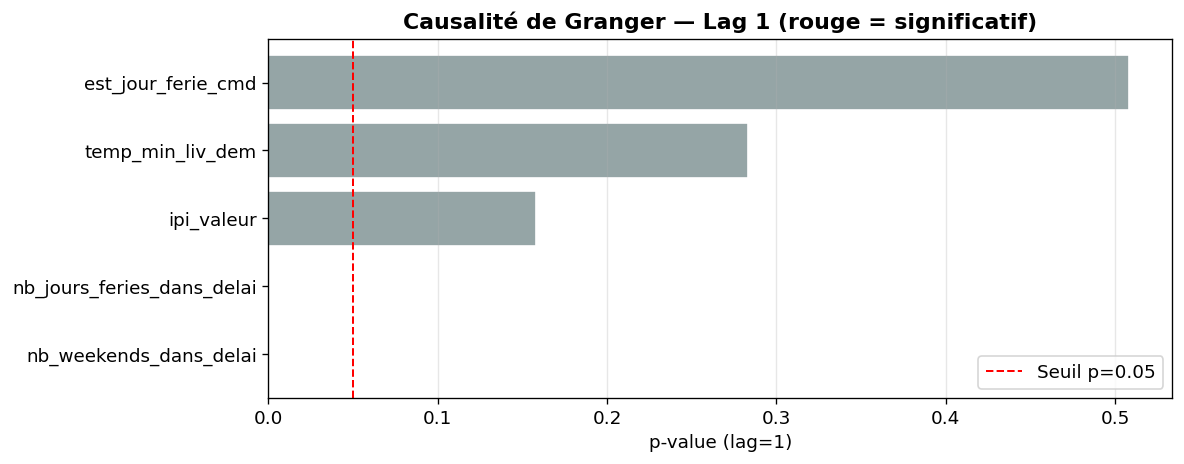

Sauvegardé → reports/granger_pvalues.png


In [27]:
# Visualisation des p-values Granger
if not df_granger.empty and 'lag_1' in df_granger.columns:
    fig, ax = plt.subplots(figsize=(10, max(4, len(df_granger) * 0.6)))

    p_lag1 = pd.to_numeric(df_granger['lag_1'], errors='coerce').dropna().sort_values()
    couleurs_g = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in p_lag1.values]

    ax.barh(p_lag1.index, p_lag1.values, color=couleurs_g, edgecolor='white')
    ax.axvline(x=0.05, color='red', linestyle='--', linewidth=1.2, label='Seuil p=0.05')
    ax.set_xlabel('p-value (lag=1)')
    ax.set_title('Causalité de Granger — Lag 1 (rouge = significatif)', fontweight='bold')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('../reports/granger_pvalues.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Sauvegardé → reports/granger_pvalues.png')

### B.4 — Rapport d'impact des facteurs externes

In [28]:
print('=' * 60)
print('RAPPORT D\'IMPACT DES FACTEURS EXTERNES — Phase 2')
print('=' * 60)

print('\n1. Corrélation Pearson avec qte_demandee (agrégé mensuel) :')
for var, val in corr_avec_cible.items():
    sig = ' ← SIGNIFICATIF (|r|>0.15)' if abs(val) > 0.15 else ''
    print(f'   {var:<42} r = {val:+.3f}{sig}')

print('\n2. Causalité de Granger (p-values) :')
if not df_granger.empty:
    print(df_granger.to_string())
    causal_vars = []
    if 'lag_1' in df_granger.columns:
        causal_vars = df_granger[
            pd.to_numeric(df_granger['lag_1'], errors='coerce') < 0.05
        ].index.tolist()
    print(f'\n   Variables causant Granger (p<0.05, lag=1) : {causal_vars}')

print('\n3. Synthèse :')
print('   → Les variables identifiées comme significatives (Pearson + Granger)')
print('     seront intégrées comme features dans le modèle XGBoost/LightGBM (Phase 3).')
print('   → Le dataset enrichi contient toutes ces variables pour la modélisation.')
print('=' * 60)

RAPPORT D'IMPACT DES FACTEURS EXTERNES — Phase 2

1. Corrélation Pearson avec qte_demandee (agrégé mensuel) :
   nb_weekends_dans_delai                     r = +0.545 ← SIGNIFICATIF (|r|>0.15)
   nb_jours_feries_dans_delai                 r = +0.497 ← SIGNIFICATIF (|r|>0.15)
   est_jour_ferie_cmd                         r = +0.198 ← SIGNIFICATIF (|r|>0.15)
   ipi_valeur                                 r = +0.174 ← SIGNIFICATIF (|r|>0.15)
   temp_min_liv_dem                           r = -0.156 ← SIGNIFICATIF (|r|>0.15)
   vent_max_kmh_liv_dem                       r = +0.149
   taux_change_devise                         r = -0.106
   est_vacances_scolaires_liv_dem             r = -0.093
   est_periode_peak_liv_dem                   r = -0.080
   est_periode_covid                          r = -0.058
   pluie_mm_liv_dem                           r = +0.033

2. Causalité de Granger (p-values) :
                             lag_1   lag_2   lag_3
nb_weekends_dans_delai      0.0000  0.0000  

---
## Sauvegarde — dataset_ml_enrichi.parquet

In [29]:
# Colonnes à supprimer (colonnes intermédiaires de jointure)
cols_a_supprimer = ['mois_liv_dem_dt', 'mois_cmd_dt', 'saison']
df_enrichi = df.drop(columns=[c for c in cols_a_supprimer if c in df.columns])

nouvelles_features = [
    'est_jour_ferie_cmd', 'est_jour_ferie_liv_dem',
    'nb_jours_feries_dans_delai', 'nb_weekends_dans_delai',
    'pluie_mm_liv_dem', 'vent_max_kmh_liv_dem', 'temp_min_liv_dem',
    'ipi_valeur', 'taux_change_devise',
    'est_vacances_scolaires_liv_dem', 'est_periode_peak_liv_dem', 'est_periode_covid',
]

print(f'Shape dataset original  : (349390, 24)')
print(f'Shape dataset enrichi   : {df_enrichi.shape}')
print(f'Nouvelles features ({len(nouvelles_features)}) : {nouvelles_features}')

output_path = '../data/processed/dataset_ml_enrichi.parquet'
df_enrichi.to_parquet(output_path, index=False)
print(f'\nDataset enrichi sauvegardé → {output_path}')

Shape dataset original  : (349390, 24)
Shape dataset enrichi   : (349390, 38)
Nouvelles features (12) : ['est_jour_ferie_cmd', 'est_jour_ferie_liv_dem', 'nb_jours_feries_dans_delai', 'nb_weekends_dans_delai', 'pluie_mm_liv_dem', 'vent_max_kmh_liv_dem', 'temp_min_liv_dem', 'ipi_valeur', 'taux_change_devise', 'est_vacances_scolaires_liv_dem', 'est_periode_peak_liv_dem', 'est_periode_covid']

Dataset enrichi sauvegardé → ../data/processed/dataset_ml_enrichi.parquet


In [30]:
# Vérification finale
df_check = pd.read_parquet(output_path)
print(f'Vérification : {df_check.shape[0]} lignes × {df_check.shape[1]} colonnes')
print('\nNaN par colonne (nouvelles features) :')
print(df_check[nouvelles_features].isna().sum())
print('\n=== Phase 2 TERMINÉE ===')
print('Livrables :')
print('  ✓ reports/decomposition_globale.png')
print('  ✓ reports/decomposition_par_famille.png')
print('  ✓ reports/cycles_budgetaires.png')
print('  ✓ reports/cycles_meteo.png')
print('  ✓ reports/matrice_correlation_pearson.png')
print('  ✓ reports/granger_pvalues.png')
print('  ✓ data/processed/dataset_ml_enrichi.parquet')

Vérification : 349390 lignes × 38 colonnes

NaN par colonne (nouvelles features) :
est_jour_ferie_cmd                0
est_jour_ferie_liv_dem            0
nb_jours_feries_dans_delai        0
nb_weekends_dans_delai            0
pluie_mm_liv_dem                  0
vent_max_kmh_liv_dem              0
temp_min_liv_dem                  0
ipi_valeur                        0
taux_change_devise                0
est_vacances_scolaires_liv_dem    0
est_periode_peak_liv_dem          0
est_periode_covid                 0
dtype: int64

=== Phase 2 TERMINÉE ===
Livrables :
  ✓ reports/decomposition_globale.png
  ✓ reports/decomposition_par_famille.png
  ✓ reports/cycles_budgetaires.png
  ✓ reports/cycles_meteo.png
  ✓ reports/matrice_correlation_pearson.png
  ✓ reports/granger_pvalues.png
  ✓ data/processed/dataset_ml_enrichi.parquet


In [33]:
pd.set_option('display.max_columns', None)

df_enrichi.head()

,qte_demandee,prix,annee_cmd,mois_cmd,trimestre_cmd,semaine_cmd,jour_semaine_cmd,est_fin_mois_cmd,annee_liv_dem,mois_liv_dem,trimestre_liv_dem,jour_semaine_liv_dem,est_weekend_liv_dem,delai_demande_jours,statut_enc,devise_enc,pays_enc,famille_activite_client_enc,famille_activite_article_enc,segment_enc,type_activite_enc,code_client_freq,code_article_freq,en_retard,date_cmd,date_liv_dem,est_jour_ferie_cmd,est_jour_ferie_liv_dem,nb_jours_feries_dans_delai,nb_weekends_dans_delai,pluie_mm_liv_dem,vent_max_kmh_liv_dem,temp_min_liv_dem,ipi_valeur,taux_change_devise,est_vacances_scolaires_liv_dem,est_periode_peak_liv_dem,est_periode_covid
0,300,89.00,2020,9,3,39,2,0,2021,1,1,4,0,114,1,1,37,2,1,4,7,296,115,1.0,2020-09-01,2021-01-01,0,1,3,34,96.2,43.7,-3.1,109.83,1.0,0,0,0
1,12,6.77,2020,10,4,41,3,0,2021,1,1,0,0,88,1,1,27,1,0,6,4,159,6253,0.0,2020-10-01,2021-01-01,0,1,3,26,96.2,43.7,-3.1,112.86,1.0,0,0,0
2,1,0.00,2020,10,4,41,3,0,2021,1,1,0,0,88,1,1,27,1,0,3,10,159,24,0.0,2020-10-01,2021-01-01,0,1,3,26,96.2,43.7,-3.1,112.86,1.0,0,0,0
3,1,19.22,2020,10,4,41,3,0,2021,1,1,0,0,88,1,1,27,1,0,6,0,159,782,0.0,2020-10-01,2021-01-01,0,1,3,26,96.2,43.7,-3.1,112.86,1.0,0,0,0
4,3,16.33,2020,10,4,41,3,0,2021,1,1,0,0,88,1,1,27,1,0,6,0,159,1632,0.0,2020-10-01,2021-01-01,0,1,3,26,96.2,43.7,-3.1,112.86,1.0,0,0,0


In [34]:
output_path = '../data/processed/dataset_ml_enrichi.parquet'
df_check = pd.read_parquet(output_path)
df_check.head()

,qte_demandee,prix,annee_cmd,mois_cmd,trimestre_cmd,semaine_cmd,jour_semaine_cmd,est_fin_mois_cmd,annee_liv_dem,mois_liv_dem,trimestre_liv_dem,jour_semaine_liv_dem,est_weekend_liv_dem,delai_demande_jours,statut_enc,devise_enc,pays_enc,famille_activite_client_enc,famille_activite_article_enc,segment_enc,type_activite_enc,code_client_freq,code_article_freq,en_retard,date_cmd,date_liv_dem,est_jour_ferie_cmd,est_jour_ferie_liv_dem,nb_jours_feries_dans_delai,nb_weekends_dans_delai,pluie_mm_liv_dem,vent_max_kmh_liv_dem,temp_min_liv_dem,ipi_valeur,taux_change_devise,est_vacances_scolaires_liv_dem,est_periode_peak_liv_dem,est_periode_covid
0,300,89.00,2020,9,3,39,2,0,2021,1,1,4,0,114,1,1,37,2,1,4,7,296,115,1.0,2020-09-01,2021-01-01,0,1,3,34,96.2,43.7,-3.1,109.83,1.0,0,0,0
1,12,6.77,2020,10,4,41,3,0,2021,1,1,0,0,88,1,1,27,1,0,6,4,159,6253,0.0,2020-10-01,2021-01-01,0,1,3,26,96.2,43.7,-3.1,112.86,1.0,0,0,0
2,1,0.00,2020,10,4,41,3,0,2021,1,1,0,0,88,1,1,27,1,0,3,10,159,24,0.0,2020-10-01,2021-01-01,0,1,3,26,96.2,43.7,-3.1,112.86,1.0,0,0,0
3,1,19.22,2020,10,4,41,3,0,2021,1,1,0,0,88,1,1,27,1,0,6,0,159,782,0.0,2020-10-01,2021-01-01,0,1,3,26,96.2,43.7,-3.1,112.86,1.0,0,0,0
4,3,16.33,2020,10,4,41,3,0,2021,1,1,0,0,88,1,1,27,1,0,6,0,159,1632,0.0,2020-10-01,2021-01-01,0,1,3,26,96.2,43.7,-3.1,112.86,1.0,0,0,0
